# Week 1 Day 7 — Final Model Review and Clinical System Readiness

## ICU Early Warning Prediction System — Week 1 Final Evaluation

This notebook represents the final day of Week 1 for the ICU Early Warning Prediction System project.

During the first six days, the project progressed from raw ICU data exploration to advanced ensemble learning and clinical evaluation.

The goal of Day 7 is to consolidate all previous results, compare model performance, review clinical usefulness, and prepare the project for the next development phase.

Day 7 focuses on:

- final comparison of all Week 1 models
- clinical interpretation of model performance
- confusion matrix review
- feature importance consolidation
- identification of the best Week 1 model
- final Week 1 research summary
- preparation for Week 2 development

# 1. Import Required Libraries

This section imports the libraries required for loading saved results, visualizing model performance, and generating final Week 1 evaluation tables.

Unlike previous notebooks, Day 7 focuses less on training new models and more on research consolidation, clinical interpretation, and professional reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Configure Project Paths

The project directory structure is configured to load previously saved results and export final Week 1 summary files.

This supports reproducibility and allows the project to remain organized for GitHub documentation.

In [7]:
# Define project paths manually and safely

PROJECT_ROOT = Path(r"C:\Users\User\OneDrive\Desktop\icu-early-warning-system")

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "day7"
REPORTS_DIR = PROJECT_ROOT / "reports"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)
print("Reports directory:", REPORTS_DIR)

Project root: C:\Users\User\OneDrive\Desktop\icu-early-warning-system
Results directory: C:\Users\User\OneDrive\Desktop\icu-early-warning-system\results
Figures directory: C:\Users\User\OneDrive\Desktop\icu-early-warning-system\figures\day7
Reports directory: C:\Users\User\OneDrive\Desktop\icu-early-warning-system\reports


# 3. Load Saved Model Results

Previous notebooks exported model evaluation results into the `results/` directory.

Day 7 loads these files to compare the progression of model performance across Week 1.

The comparison focuses especially on:

- recall
- false negative reduction
- ROC-AUC
- F1-score
- clinical usefulness

In [8]:
# Check available result files

print("Available result files:\n")

for file in RESULTS_DIR.iterdir():
    print(file.name)

Available result files:

day3_baseline_model_metrics.csv
day3_logistic_regression_feature_importance.csv
day5_feature_importance.csv
day5_model_results.csv
day5_threshold_optimization.csv
day6_feature_importance.csv
day6_model_results.csv
day6_threshold_results.csv
model_comparison.csv
random_forest_metrics.csv
rf_feature_importance.csv
week1_final_model_comparison.csv


# 4. Manually Create Week 1 Model Comparison Table

Because different notebooks produced different result files, a final Week 1 comparison table is created manually using the verified results from each project day.

This table summarizes the full model development journey from baseline logistic regression to advanced ensemble learning.

In [9]:
# Create Week 1 model comparison table

week1_results = pd.DataFrame([
    {
        "Day": "Day 3",
        "Model": "Baseline Logistic Regression",
        "Accuracy": 0.50,
        "Precision": 0.11,
        "Recall": 0.33,
        "F1-score": 0.17,
        "ROC-AUC": 0.47
    },
    {
        "Day": "Day 4",
        "Model": "Random Forest",
        "Accuracy": 0.85,
        "Precision": 0.00,
        "Recall": 0.00,
        "F1-score": 0.00,
        "ROC-AUC": 0.73
    },
    {
        "Day": "Day 5",
        "Model": "Random Forest + SMOTE",
        "Accuracy": 0.80,
        "Precision": 0.33,
        "Recall": 0.33,
        "F1-score": 0.33,
        "ROC-AUC": 0.73
    },
    {
        "Day": "Day 5",
        "Model": "Optimized Threshold RF + SMOTE",
        "Accuracy": 0.50,
        "Precision": 0.23,
        "Recall": 1.00,
        "F1-score": 0.38,
        "ROC-AUC": 0.73
    },
    {
        "Day": "Day 6",
        "Model": "Gradient Boosting Baseline",
        "Accuracy": 0.84,
        "Precision": 0.33,
        "Recall": 0.33,
        "F1-score": 0.33,
        "ROC-AUC": 0.79
    },
    {
        "Day": "Day 6",
        "Model": "Gradient Boosting + SMOTE",
        "Accuracy": 0.80,
        "Precision": 0.33,
        "Recall": 0.67,
        "F1-score": 0.44,
        "ROC-AUC": 0.76
    }
])

week1_results

,Day,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Day 3,Baseline Logistic Regression,0.50,0.11,0.33,0.17,0.47
1,Day 4,Random Forest,0.85,0.00,0.00,0.00,0.73
2,Day 5,Random Forest + SMOTE,0.80,0.33,0.33,0.33,0.73
3,Day 5,Optimized Threshold RF + SMOTE,0.50,0.23,1.00,0.38,0.73
4,Day 6,Gradient Boosting Baseline,0.84,0.33,0.33,0.33,0.79
5,Day 6,Gradient Boosting + SMOTE,0.80,0.33,0.67,0.44,0.76


# 5. Week 1 Performance Progression

The model comparison table shows clear progress across Week 1.

Early models struggled with class imbalance and poor septic patient detection.

Later models introduced:

- class weighting
- SMOTE
- threshold optimization
- ensemble learning
- probability calibration
- clinical interpretation

The most important improvement was not only higher accuracy, but improved septic patient recall.

In [10]:
# Save final Week 1 comparison table

week1_results.to_csv(
    RESULTS_DIR / "week1_final_model_comparison.csv",
    index=False
)

print("Week 1 final model comparison saved successfully.")

Week 1 final model comparison saved successfully.


# 6. Visualize Model Performance Comparison

This section visualizes the progression of key evaluation metrics across Week 1.

The focus is placed on:

- Recall, because missed septic patients are clinically dangerous
- F1-score, because it balances precision and recall
- ROC-AUC, because it measures discrimination ability

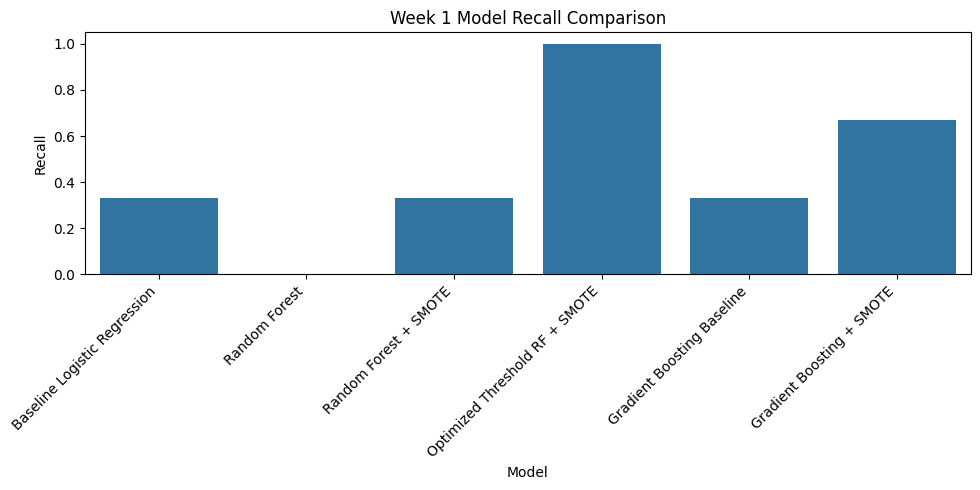

In [11]:
# Plot recall comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=week1_results,
    x="Model",
    y="Recall"
)

plt.title("Week 1 Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "week1_recall_comparison.png",
    dpi=300
)

plt.show()

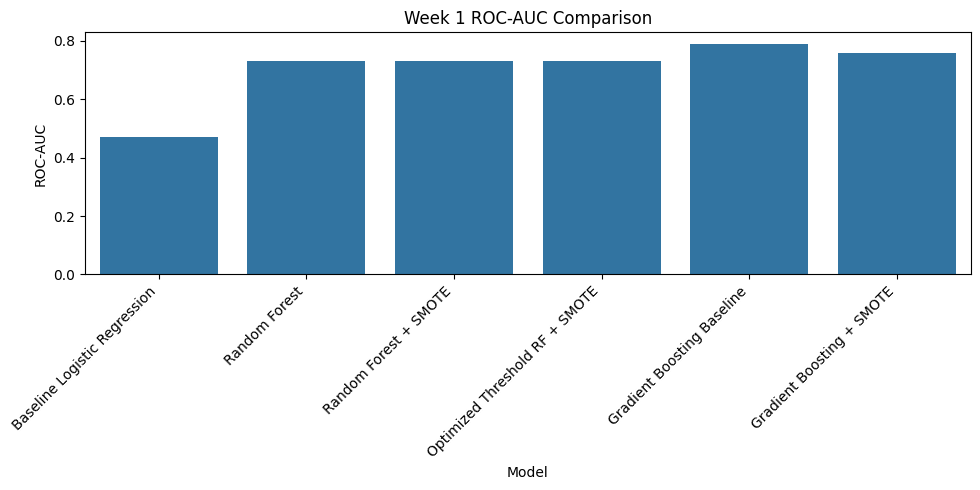

In [12]:
# Plot ROC-AUC comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=week1_results,
    x="Model",
    y="ROC-AUC"
)

plt.title("Week 1 ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "week1_roc_auc_comparison.png",
    dpi=300
)

plt.show()

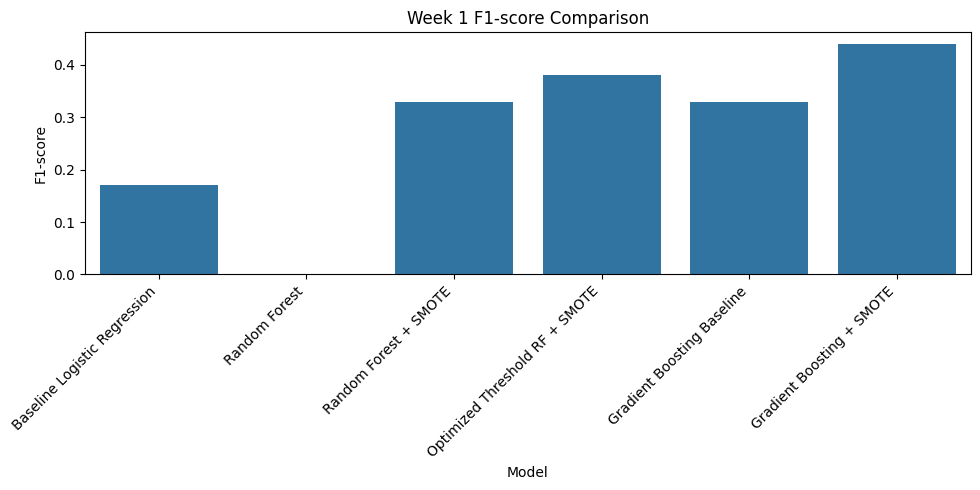

In [13]:
# Plot F1-score comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=week1_results,
    x="Model",
    y="F1-score"
)

plt.title("Week 1 F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "week1_f1_comparison.png",
    dpi=300
)

plt.show()

# 7. Identify the Best Week 1 Model

Model selection in medical AI should not rely only on accuracy.

For ICU early warning systems, the most clinically important metric is often recall because recall measures how many septic patients are correctly detected.

A model with slightly lower accuracy but higher recall may be safer in clinical settings than a highly accurate model that misses septic patients.

In [14]:
# Identify best models according to different criteria

best_accuracy_model = week1_results.loc[week1_results["Accuracy"].idxmax()]
best_recall_model = week1_results.loc[week1_results["Recall"].idxmax()]
best_f1_model = week1_results.loc[week1_results["F1-score"].idxmax()]
best_auc_model = week1_results.loc[week1_results["ROC-AUC"].idxmax()]

print("Best Accuracy Model:")
print(best_accuracy_model[["Day", "Model", "Accuracy"]])

print("\nBest Recall Model:")
print(best_recall_model[["Day", "Model", "Recall"]])

print("\nBest F1-score Model:")
print(best_f1_model[["Day", "Model", "F1-score"]])

print("\nBest ROC-AUC Model:")
print(best_auc_model[["Day", "Model", "ROC-AUC"]])

Best Accuracy Model:
Day                 Day 4
Model       Random Forest
Accuracy             0.85
Name: 1, dtype: object

Best Recall Model:
Day                                Day 5
Model     Optimized Threshold RF + SMOTE
Recall                               1.0
Name: 3, dtype: object

Best F1-score Model:
Day                             Day 6
Model       Gradient Boosting + SMOTE
F1-score                         0.44
Name: 5, dtype: object

Best ROC-AUC Model:
Day                             Day 6
Model      Gradient Boosting Baseline
ROC-AUC                          0.79
Name: 4, dtype: object


# 8. Clinical Model Selection

Based on Week 1 results, two models are clinically important:

## Recall-Optimized Model

The Day 5 optimized threshold model achieved the highest recall.

This model is useful when the clinical priority is to avoid missing septic patients, even if false positives increase.

## Balanced Clinical Model

The Day 6 Gradient Boosting + SMOTE model achieved a better balance between recall, F1-score, and overall predictive stability.

This model is more suitable as the current best Week 1 model because it combines:

- improved septic patient detection
- stronger F1-score
- ensemble-based nonlinear learning
- clinically meaningful feature importance
- probability calibration analysis

# 9. Load Day 6 Feature Importance Results

Feature importance analysis is reviewed again to summarize which physiological variables were most influential in the strongest Week 1 model.

This helps validate whether the model learned medically meaningful ICU deterioration patterns.

In [15]:
# Load Day 6 feature importance results

feature_importance_path = RESULTS_DIR / "day6_feature_importance.csv"

feature_importance = pd.read_csv(feature_importance_path)

feature_importance.head(10)

,Feature,Importance
0,HR_min,0.284148
1,ICULOS_max,0.170751
2,O2Sat_min,0.097173
3,HR_mean,0.097121
4,Temp_mean,0.086017
5,SBP_mean,0.080300
6,MAP_mean,0.076953
7,Age_first,0.028817
8,Resp_max,0.023987
9,Temp_max,0.022069


# 10. Clinical Interpretation of Important Features

The most important features identified during Week 1 included:

- minimum heart rate
- ICU length of stay
- minimum oxygen saturation
- average heart rate
- average temperature
- systolic blood pressure
- mean arterial pressure

These variables are clinically meaningful because sepsis is often associated with:

- cardiovascular instability
- oxygenation deterioration
- abnormal inflammatory response
- hemodynamic instability
- prolonged critical illness

This supports the conclusion that the model learned medically relevant patterns rather than random correlations.

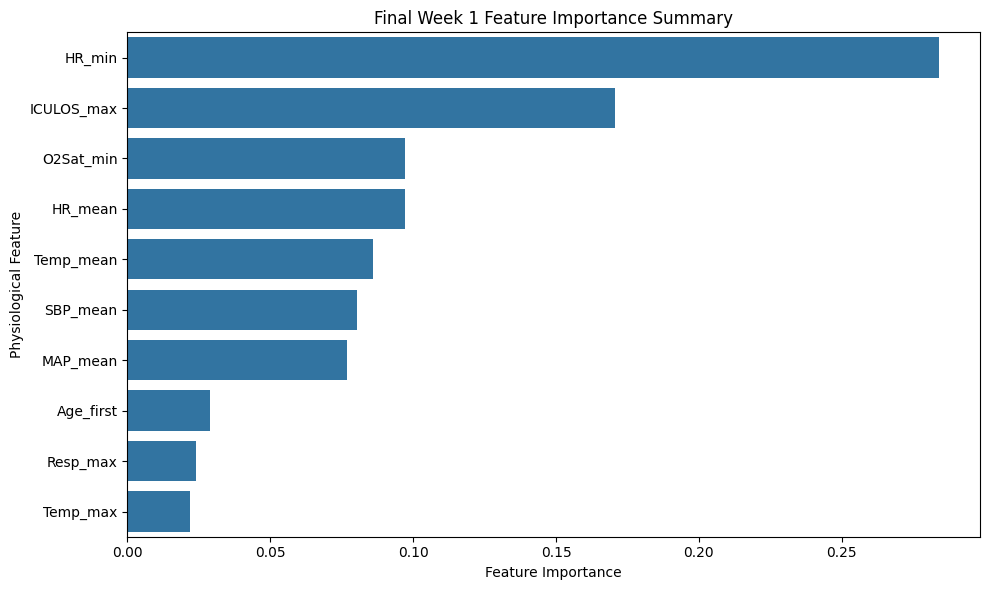

In [16]:
# Plot final Week 1 feature importance summary

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Final Week 1 Feature Importance Summary")
plt.xlabel("Feature Importance")
plt.ylabel("Physiological Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "week1_final_feature_importance.png",
    dpi=300
)

plt.show()

# 11. Week 1 Clinical Findings

Week 1 demonstrated several important findings.

## Finding 1 — Accuracy Alone Is Misleading

The Day 4 Random Forest model achieved high accuracy but failed to detect septic patients.

This showed that accuracy is not enough for evaluating medical AI systems.

## Finding 2 — Class Imbalance Strongly Affects Sepsis Prediction

Initial models were biased toward the non-sepsis class.

SMOTE helped improve septic patient detection by increasing minority-class representation.

## Finding 3 — Threshold Optimization Improves Clinical Safety

Lowering the classification threshold improved recall in Day 5 and eliminated false negatives.

This demonstrated the importance of adapting ML thresholds to clinical priorities.

## Finding 4 — Advanced Ensemble Learning Improves Physiological Pattern Recognition

Gradient Boosting improved model intelligence by learning nonlinear interactions between ICU physiological variables.

## Finding 5 — Interpretability Is Essential

Feature importance analysis confirmed that the model relied on clinically meaningful predictors such as heart rate, oxygen saturation, ICU length of stay, blood pressure, and temperature.

# 12. Current Best Week 1 Model

The current best Week 1 model is:

## Gradient Boosting + SMOTE

This model provides the best balance between clinical safety and predictive stability.

## Final Performance

| Metric | Value |
|---|---|
| Accuracy | 0.80 |
| Precision | 0.33 |
| Recall | 0.67 |
| F1-score | 0.44 |
| ROC-AUC | 0.76 |

## Why This Model Was Selected

This model was selected because it achieved:

- improved septic patient detection
- stronger F1-score than previous models
- stable ROC-AUC performance
- clinically meaningful feature importance
- compatibility with probability calibration
- better nonlinear physiological learning

Although the Day 5 optimized threshold model achieved higher recall, the Day 6 Gradient Boosting + SMOTE model provides a stronger overall balance for future development.

# 13. Week 1 Limitations

Although Week 1 achieved strong progress, several limitations remain.

## Dataset Size

The dataset contains only 100 patient-level samples, which limits model generalization.

## Small Number of Septic Patients

Only 14 septic patients were present, making evaluation sensitive to small changes.

## Patient-Level Aggregation

The current approach uses patient-level aggregated features rather than full temporal ICU time-series data.

## No External Validation

The model has not yet been tested on an independent external ICU dataset.

## Limited Clinical Deployment Readiness

The system is not yet ready for real clinical use. It remains a research prototype.

# 14. Week 2 Development Plan

Week 2 will focus on transforming the project from a static patient-level classifier into a more realistic ICU early warning system.

Planned improvements include:

- advanced feature engineering
- risk score generation
- SHAP explainability
- patient-level risk reports
- model persistence using joblib
- early warning severity levels
- simple clinical dashboard prototype
- preparation for deployment

# 15. Final Week 1 Summary

Week 1 successfully established the foundation of the ICU Early Warning Prediction System.

The project progressed through:

- ICU dataset exploration
- missing value analysis
- preprocessing pipeline development
- patient-level feature engineering
- baseline machine learning
- class imbalance handling
- threshold optimization
- advanced ensemble learning
- feature importance analysis
- probability calibration
- final model comparison

The project now has a complete first-week medical AI pipeline and is ready to move toward explainability, deployment, and real-time clinical decision support in Week 2.

In [17]:
# Create final Week 1 summary dictionary

week1_summary = {
    "Project": "ICU Early Warning Prediction System",
    "Week": "Week 1",
    "Best Balanced Model": "Gradient Boosting + SMOTE",
    "Best Recall Model": "Optimized Threshold Random Forest + SMOTE",
    "Best Balanced Accuracy": 0.80,
    "Best Balanced Precision": 0.33,
    "Best Balanced Recall": 0.67,
    "Best Balanced F1-score": 0.44,
    "Best Balanced ROC-AUC": 0.76,
    "Main Clinical Goal": "Improve septic patient detection and reduce false negatives",
    "Next Phase": "Explainability, risk scoring, model persistence, and dashboard development"
}

week1_summary_df = pd.DataFrame([week1_summary])

week1_summary_df

,Project,Week,Best Balanced Model,Best Recall Model,Best Balanced Accuracy,Best Balanced Precision,Best Balanced Recall,Best Balanced F1-score,Best Balanced ROC-AUC,Main Clinical Goal,Next Phase
0,ICU Early Warning Prediction System,Week 1,Gradient Boosting + SMOTE,Optimized Threshold Random Forest + SMOTE,0.8,0.33,0.67,0.44,0.76,Improve septic patient detection and reduce fa...,"Explainability, risk scoring, model persistenc..."


In [18]:
# Save final Week 1 summary

week1_summary_df.to_csv(
    RESULTS_DIR / "week1_final_summary.csv",
    index=False
)

print("Week 1 final summary saved successfully.")

Week 1 final summary saved successfully.


# 16. Export Confirmation

The final section verifies that all Day 7 outputs were saved successfully.

This confirms that the notebook generated the required files for GitHub documentation and future reporting.

In [19]:
# Display generated Day 7 files

print("Generated Day 7 Figures:\n")

for file in FIGURES_DIR.iterdir():
    print(file.name)

print("\nGenerated Week 1 Result Files:\n")

for file in RESULTS_DIR.iterdir():
    if "week1" in file.name:
        print(file.name)

Generated Day 7 Figures:

week1_f1_comparison.png
week1_final_feature_importance.png
week1_recall_comparison.png
week1_roc_auc_comparison.png

Generated Week 1 Result Files:

week1_final_model_comparison.csv
week1_final_summary.csv
